In [1]:
import sys
import os
# Add project root to path so we can import eval_utils
sys.path.append(os.path.abspath('..'))

import pandas as pd
from eval_utils import normalize_label, specificity_multiclass, plot_confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score

# 1. Load baseline results
df = pd.read_csv("final_results/gpt-baseline.csv")

# 2. Normalize labels
df['diagnosis'] = df['diagnosis'].apply(normalize_label)
df['ground_truth'] = df['ground_truth'].apply(normalize_label)
df.dropna(subset=["diagnosis"], inplace=True)

print(f"Loaded {len(df)} cases for evaluation.")
df.head(5)

Loaded 300 cases for evaluation.


,case_id,diagnosis,confidence,differential_diagnosis,reasoning,ground_truth
0,ISIC_0025686,Melanoma,Medium,Nevus,"Lesion shows an asymmetric, ill-defined browni...",Nevus
1,ISIC_0031196,Actinic Keratosis,Medium,Pigmented benign keratosis,Clinical metadata: 45-year-old male lesion on ...,Pigmented benign keratosis
2,ISIC_0030535,Nevus,High,Pigmented benign keratosis,"Image shows a small, symmetric, well-circumscr...",Nevus
3,ISIC_0024994,Squamous cell carcinoma,Medium,Actinic keratosis,Non-melanocytic lesion (metadata flag false) w...,Dermatofibroma
4,ISIC_0024944,Nevus,Medium,Melanoma,"The lesion is a relatively symmetric, well-dem...",Nevus


In [2]:
print("Diagnosis distribution:")
print(df["diagnosis"].value_counts())

Diagnosis distribution:
diagnosis
Melanoma                      99
Nevus                         71
Pigmented benign keratosis    60
Actinic Keratosis             39
Squamous cell carcinoma       15
Basal cell carcinoma           9
Dermatofibroma                 7
Name: count, dtype: int64


In [3]:
y_true = df["ground_truth"]
y_pred = df["diagnosis"]

acc = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
spec_results = specificity_multiclass(y_true, y_pred)
report = classification_report(y_true, y_pred, digits=4)
    
print(f"✅ Overall Accuracy: {acc:.4f}")
print(f"✅ Cohen's Kappa: {kappa:.4f}\n")
print(f"📊 Macro-average Specificity: {spec_results['macro_avg']:.4f}")
print(f"📈 Weighted-average Specificity: {spec_results['weighted_avg']:.4f}")
print("\n📊 Classification Report:\n", report)

✅ Overall Accuracy: 0.4700
✅ Cohen's Kappa: 0.3436

📊 Macro-average Specificity: 0.9133
📈 Weighted-average Specificity: 0.9230

📊 Classification Report:
                             precision    recall  f1-score   support

         Actinic Keratosis     0.1282    0.3333    0.1852        15
      Basal cell carcinoma     0.5556    0.1667    0.2564        30
            Dermatofibroma     0.7143    0.3125    0.4348        16
                  Melanoma     0.3434    0.8500    0.4892        40
                     Nevus     0.9296    0.4853    0.6377       136
Pigmented benign keratosis     0.4000    0.6000    0.4800        40
   Squamous cell carcinoma     0.1333    0.0870    0.1053        23

                  accuracy                         0.4700       300
                 macro avg     0.4578    0.4050    0.3698       300
              weighted avg     0.6308    0.4700    0.4845       300



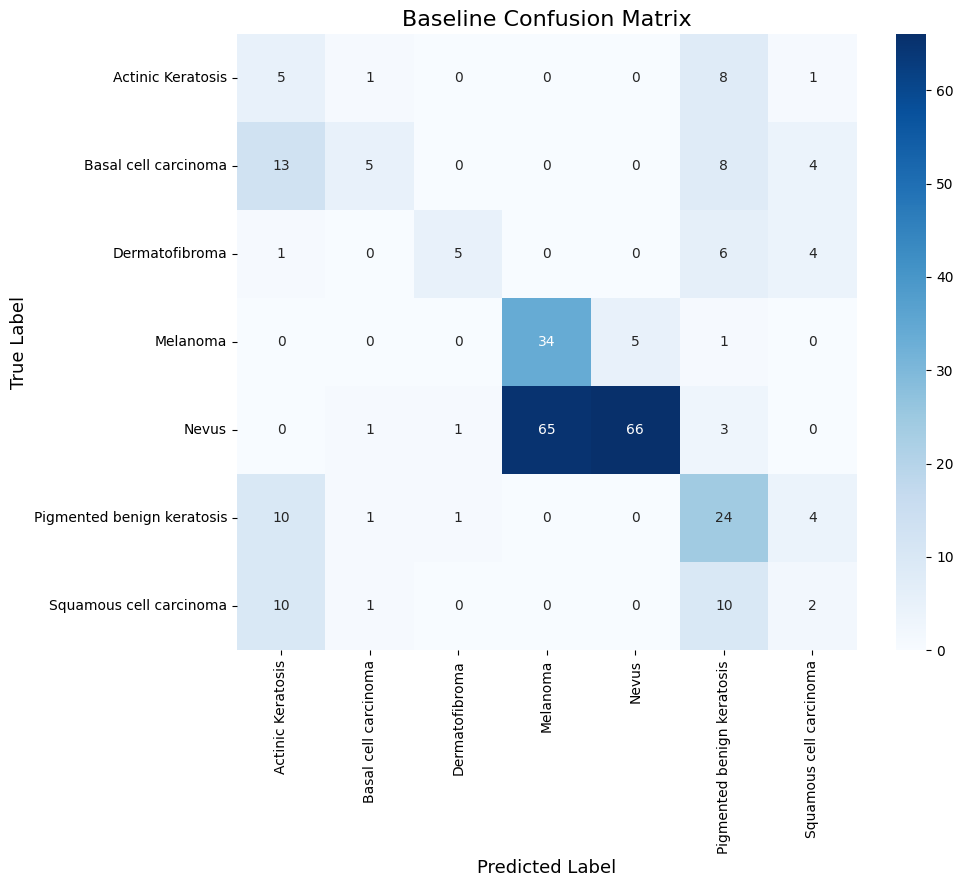

In [4]:
class_labels = sorted(list(set(y_true) | set(y_pred)))
plot_confusion_matrix(y_true, y_pred, class_labels=class_labels, title='Baseline Confusion Matrix')